In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [2]:
df_solubility = pd.read_csv('solubility.csv')

In [3]:
# 1. Show the first few rows of the dataset
print("First 5 rows:")
display(df_solubility.head())

# 2. Summary of dataset: columns, non-null counts, and data types
print("\nDataset info:")
df_solubility.info()

# 3. Basic statistics for numerical columns
print("\nStatistical summary:")
display(df_solubility.describe())

# 4. Check for missing values in each column
print("\nMissing values per column:")
print(df_solubility.isnull().sum())

# 5. Check the column names to identify features and target variable
print("\nColumns in dataset:")
print(df_solubility.columns.tolist())

# 6. Display data types of each column
print("\nData types:")
print(df_solubility.dtypes)

First 5 rows:


,Compound ID,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,2,84.143,0,1,0,0.00,-1.33,c1ccsc1



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Compound ID                                1128 non-null   object 
 1   Minimum Degree                             1128 non-null   int64  
 2   Molecular Weight                           1128 non-null   float64
 3   Number of H-Bond Donors                    1128 non-null   int64  
 4   Number of Rings                            1128 non-null   int64  
 5   Number of Rotatable Bonds                  1128 non-null   int64  
 6   Polar Surface Area                         1128 non-null   float64
 7   measured log solubility in mols per litre  1128 non-null   float64
 8   smiles                                     1128 non-null   object 
dtypes: float64(3), int64(4), object(2)
memory usage: 79.4+ KB

Statistical summary:


,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre
count,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000,1128.000000
mean,1.058511,203.937074,0.701241,1.390957,2.177305,34.872881,-3.050102
std,0.238560,102.738077,1.089727,1.318286,2.640974,35.383593,2.096441
min,0.000000,16.043000,0.000000,0.000000,0.000000,0.000000,-11.600000
25%,1.000000,121.183000,0.000000,0.000000,0.000000,0.000000,-4.317500
50%,1.000000,182.179000,0.000000,1.000000,1.000000,26.300000,-2.860000
75%,1.000000,270.372000,1.000000,2.000000,3.000000,55.440000,-1.600000
max,2.000000,780.949000,11.000000,8.000000,23.000000,268.680000,1.580000



Missing values per column:
Compound ID                                  0
Minimum Degree                               0
Molecular Weight                             0
Number of H-Bond Donors                      0
Number of Rings                              0
Number of Rotatable Bonds                    0
Polar Surface Area                           0
measured log solubility in mols per litre    0
smiles                                       0
dtype: int64

Columns in dataset:
['Compound ID', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']

Data types:
Compound ID                                   object
Minimum Degree                                 int64
Molecular Weight                             float64
Number of H-Bond Donors                        int64
Number of Rings                                int64
Number of Rotatable Bonds      

## 🔍 Dataset Exploration Summary

The dataset contains **1,128 molecules**, each represented by a set of chemical and structural descriptors along with a solubility measurement.

### ✅ Columns Overview

| Column Name                                  | Type     | Description                                                                 |
|---------------------------------------------|----------|-----------------------------------------------------------------------------|
| `Compound ID`                                | object   | Unique identifier or name of the compound.                                 |
| `Minimum Degree`                             | int      | Minimum number of connections (bonds) an atom in the molecule has.         |
| `Molecular Weight`                           | float    | Molecular mass in atomic mass units (amu).                                 |
| `Number of H-Bond Donors`                    | int      | Number of atoms in the molecule that can donate hydrogen bonds.            |
| `Number of Rings`                            | int      | Count of ring structures in the molecule.                                  |
| `Number of Rotatable Bonds`                  | int      | Flexibility of the molecule — high values indicate more rotatable bonds.   |
| `Polar Surface Area`                         | float    | Surface area of polar atoms; affects solubility and permeability.          |
| `measured log solubility in mols per litre`  | float    | **Target variable**: logS value indicating solubility.                     |
| `smiles`                                     | object   | SMILES string — text representation of molecular structure.                |

---

### 📊 Key Observations

- All columns are **complete** — there are **no missing values**.
- Most features are numerical and suitable for regression modeling.
- `logS` (measured log solubility) ranges from **-11.6 to 1.58**, indicating high variation in solubility across compounds.
- Features such as **molecular weight**, **H-bond donors**, **rotatable bonds**, and **polar surface area** are likely to be important for predicting solubility.
- The `smiles` and `Compound ID` columns are **non-numeric**:
  - `Compound ID` is mostly for display or grouping.
  - `smiles` could be used with molecular fingerprinting or embedding techniques (if desired).

---

C:\Users\Ntyum\AppData\Local\Temp\ipykernel_6480\1154419451.py:9: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ntyum\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


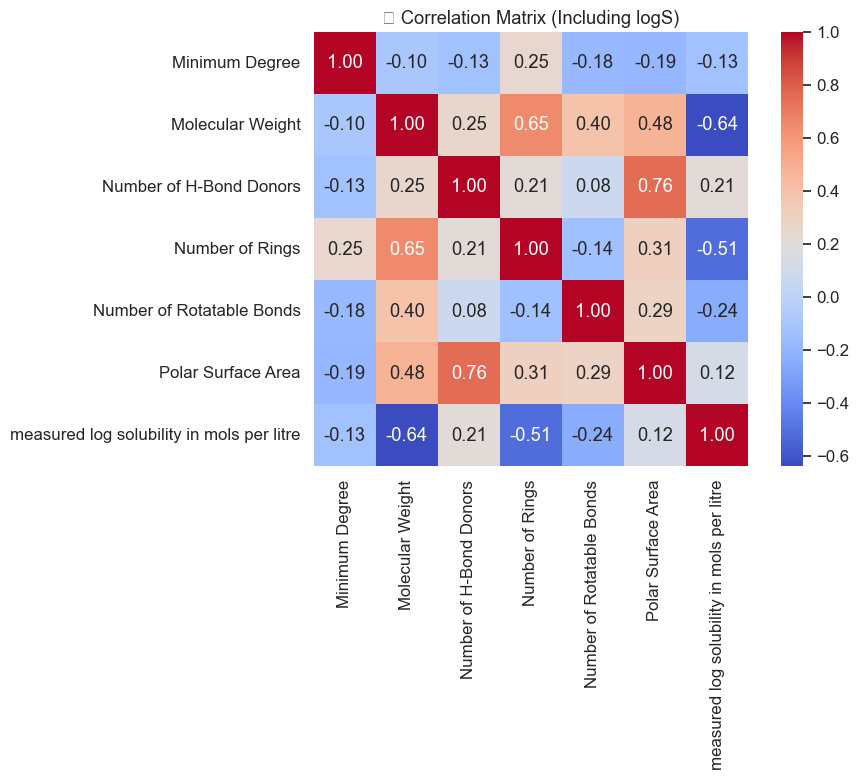

C:\Users\Ntyum\AppData\Local\Temp\ipykernel_6480\1154419451.py:18: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ntyum\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


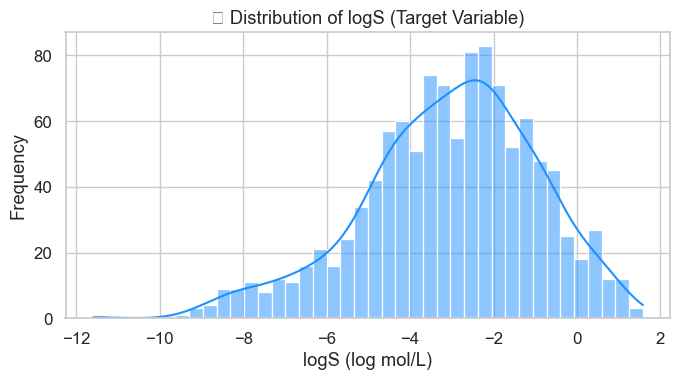

C:\Users\Ntyum\AppData\Local\Temp\ipykernel_6480\1154419451.py:29: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ntyum\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


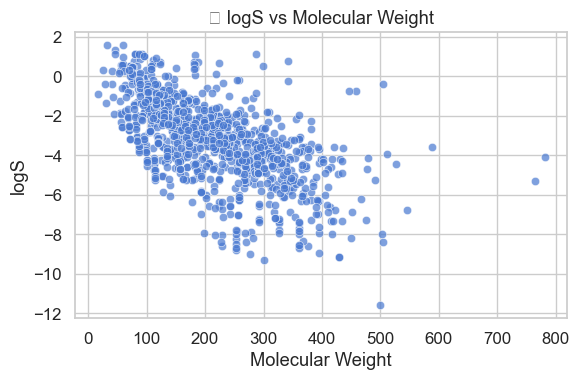

C:\Users\Ntyum\AppData\Local\Temp\ipykernel_6480\1154419451.py:29: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ntyum\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


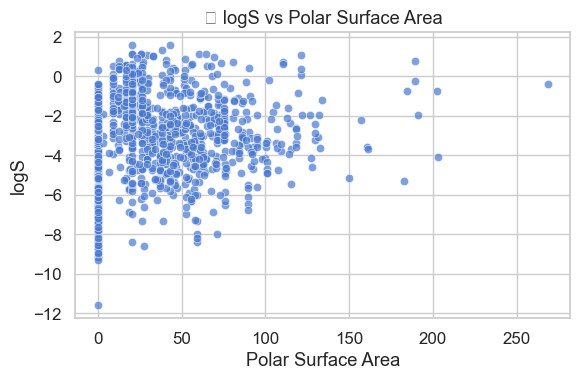

C:\Users\Ntyum\AppData\Local\Temp\ipykernel_6480\1154419451.py:29: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ntyum\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


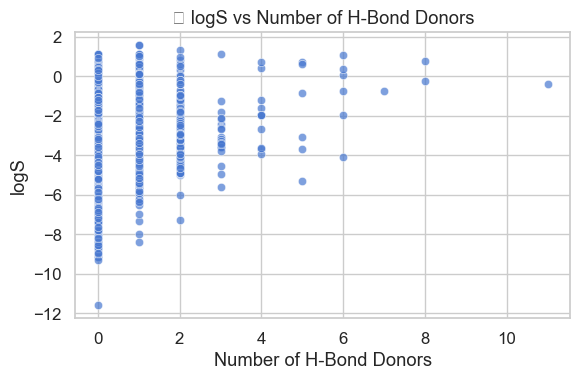

C:\Users\Ntyum\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


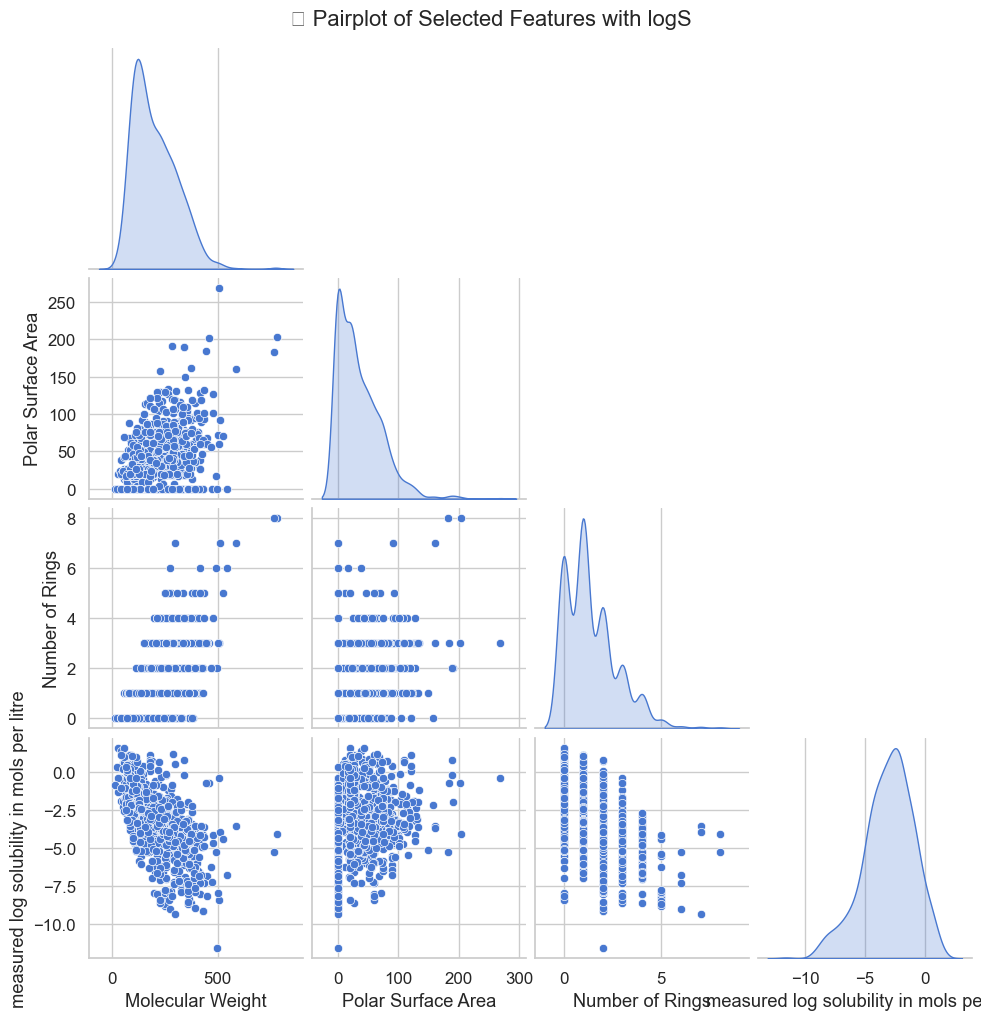

C:\Users\Ntyum\AppData\Local\Temp\ipykernel_6480\1154419451.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_solubility, x='Number of Rings', palette="Set2")
C:\Users\Ntyum\AppData\Local\Temp\ipykernel_6480\1154419451.py:44: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Ntyum\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


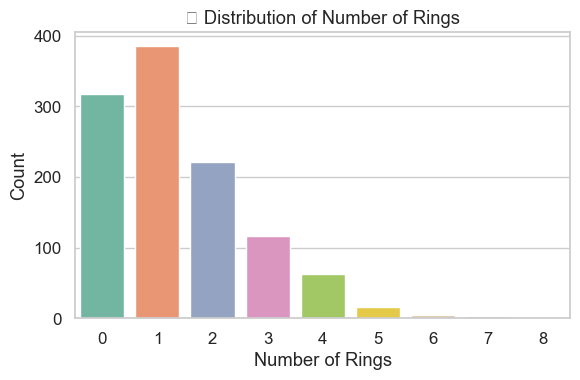

In [8]:
# Set visual theme
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# 1. Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df_solubility.drop(['Compound ID', 'smiles'], axis=1).corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("🔍 Correlation Matrix (Including logS)")
plt.tight_layout()
plt.show()

# 2. Distribution of the target variable (logS)
plt.figure(figsize=(7, 4))
sns.histplot(df_solubility['measured log solubility in mols per litre'], bins=40, kde=True, color='dodgerblue')
plt.title("📈 Distribution of logS (Target Variable)")
plt.xlabel("logS (log mol/L)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# 3. Boxplots of key numeric features vs logS
features = ['Molecular Weight', 'Polar Surface Area', 'Number of H-Bond Donors']
for feature in features:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df_solubility, x=feature, y='measured log solubility in mols per litre', alpha=0.7)
    plt.title(f"📉 logS vs {feature}")
    plt.ylabel("logS")
    plt.xlabel(feature)
    plt.tight_layout()
    plt.show()

# 4. Pairplot of selected features with logS
selected_features = ['Molecular Weight', 'Polar Surface Area', 'Number of Rings', 'measured log solubility in mols per litre']
sns.pairplot(df_solubility[selected_features], diag_kind="kde", corner=True)
plt.suptitle("🔗 Pairplot of Selected Features with logS", y=1.02)
plt.show()

# 5. Count plot of Number of Rings (categorical distribution)
plt.figure(figsize=(6, 4))
sns.countplot(data=df_solubility, x='Number of Rings', palette="Set2")
plt.title("🔢 Distribution of Number of Rings")
plt.xlabel("Number of Rings")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 🔍 Correlation Insights from Heatmap

- **Molecular Weight** has the strongest **negative correlation** with solubility (`logS`): **-0.64**. This suggests that heavier molecules tend to be less soluble.
- **Number of Rings** also shows a strong **negative correlation** with solubility: **-0.51**. More ring structures may reduce solubility.
- **Number of Rotatable Bonds** is weakly negatively correlated with solubility: **-0.24**. Molecules with more flexibility may also have reduced aqueous solubility.
- **Polar Surface Area (PSA)** is **positively correlated** with solubility (**+0.12**) but only weakly. This is interesting, as PSA often contributes to solubility, but the effect is less pronounced here.
- **Number of H-Bond Donors** shows a **small positive correlation** with solubility: **+0.21**, indicating that hydrogen bonding capacity might slightly enhance solubility.
- **Minimum Degree** has a very weak negative correlation with solubility: **-0.13**, and is likely not a useful predictor on its own.

### 📌 Summary:

- Focus on features like **Molecular Weight** and **Number of Rings** as potentially strong predictors of solubility.
- PSA and H-Bond Donors might help in combination with other features but show weaker standalone effects.
- a correlation of 0.76 between Polar Surface Area (PSA) and Number of H-Bond Donors is strong and can introduce multicollinearity, particularly in linear models like linear regression.

In [11]:
X_vif = df_solubility[['Polar Surface Area', 'Number of H-Bond Donors']]
X_vif = add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(vif_data)

                   feature       VIF
0                    const  1.996272
1       Polar Surface Area  2.333358
2  Number of H-Bond Donors  2.333358


Since both values are well below the threshold of **5**, there is **no significant multicollinearity concern**.

In [4]:
df = df_solubility.copy()

# 🎯 Define Features and Target
X = df.drop(columns=['Compound ID', 'measured log solubility in mols per litre', 'smiles'])
y = df['measured log solubility in mols per litre']

### 📋 Feature Selection Summary

| Column                                      | Reason                                                              |
|---------------------------------------------|---------------------------------------------------------------------|
| `Compound ID`                               | Non-numeric identifier with no chemical meaning                     |
| `measured log solubility in mols per litre` | Target variable — should not be part of the input features          |
| `smiles`                                    | Requires preprocessing — not usable as-is in standard regression    |



📊 Linear Regression Performance:
R² Score: 0.6961
MAE: 0.8917
RMSE: 1.1986

📊 Random Forest Regression Performance:
R² Score: 0.8258
MAE: 0.6043
RMSE: 0.9075


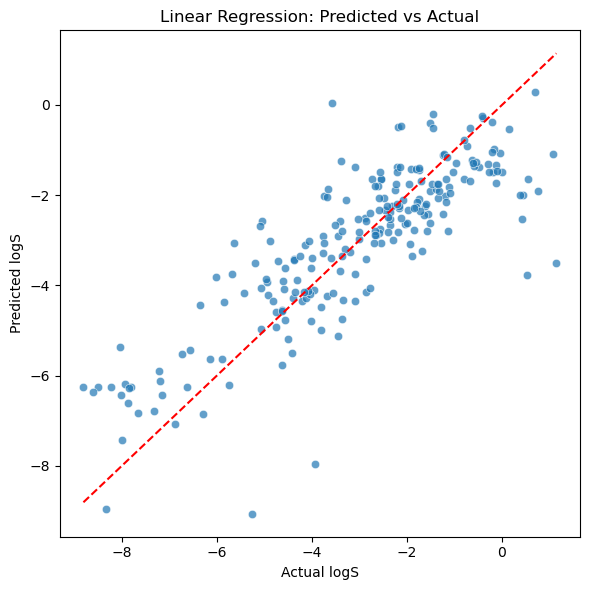

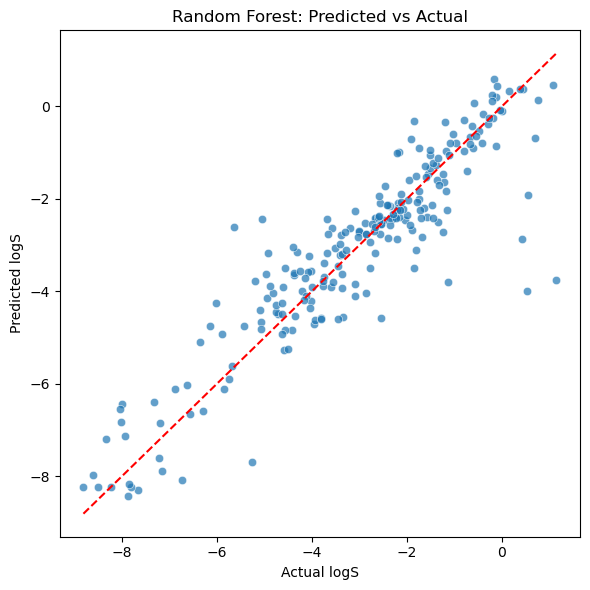

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 1️⃣ Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# --- 2️⃣ Random Forest Regression ---
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

def evaluate_model(name, y_test, y_pred):
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)  # Compute RMSE manually
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\n📊 {name} Performance:")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

# 📊 Evaluation
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest Regression", y_test, y_pred_rf)

# 📉 Visualization Function
def plot_predictions(y_test, y_pred, title):
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual logS")
    plt.ylabel("Predicted logS")
    plt.title(title)
    plt.tight_layout()
    plt.show()


#  Visualize Predictions
plot_predictions(y_test, y_pred_lr, "Linear Regression: Predicted vs Actual")
plot_predictions(y_test, y_pred_rf, "Random Forest: Predicted vs Actual")